# 05. cuPF GPU: Jacobian fill과 sparse solve의 위치 바꾸기

**목표**
- GPU path가 Newton 구조에서 어느 비용을 GPU로 옮기는지 확인한다.
- `initialize_ms`와 `solve_ms`를 분리해서 읽는다.
- Edge/EdgeAtomic/VertexWarp 비교가 전체 solve time에 얼마나 보이는지 해석한다.

**GPU path 구성 요소**
- `cuda_cudss.cpp`: cuDSS handle, sparse matrix descriptor, factorization/solve 연결
- CUDA Jacobian fill: `Edge`, `EdgeAtomic`, `VertexWarp`
- custom solver: 범용 cuDSS와 비교하기 위한 연구용 linear solve path

**Timing phase 구분**
- `initialize_ms`: Ybus pattern, bus partition, CUDA/cuDSS resource, symbolic analysis 준비 비용
- `solve_ms`: Newton 반복의 mismatch, Jacobian fill, numeric factorization, linear solve, update 비용

**읽는 법**
- 단일 케이스 latency에서는 initialize 비용이 크게 보일 수 있다.
- 같은 topology를 여러 scenario에 재사용하면 initialize 비용은 amortize 대상이다.
- solve phase까지 CPU KLU보다 길면, 현재 조건에서는 GPU direct solve가 자동 이득이 아니라는 뜻이다.
- edge/vertex 차이가 작으면 Jacobian fill보다 sparse factorization/solve가 더 크게 보인다는 단서다.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'cuPF').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from python.tutorial import tutorial_utils as tu

plt.rcParams['figure.figsize'] = (8, 4.8)
plt.rcParams['axes.grid'] = False
pd.set_option('display.max_colwidth', 120)

TUTORIAL_CASE = tu.TUTORIAL_LARGE_CASE
RUN_BENCHMARKS = True
REPEATS = 1
WARMUP = 0


In [2]:
display(pd.DataFrame([
    {'variant': 'cupf-cpu-klu', 'role': 'CPU reference after KLU/native Jacobian optimization'},
    {'variant': 'cupf-fp64-cudss', 'role': 'GPU Jacobian Edge + cuDSS sparse solve'},
    {'variant': 'cupf-fp64-cudss-edge-atomic', 'role': 'legacy edge fill with atomic diagonal accumulation'},
    {'variant': 'cupf-fp64-cudss-vertex-warp', 'role': 'warp-per-bus style vertex fill'},
]))


,variant,role
0,cupf-cpu-klu,CPU reference after KLU/native Jacobian optimization
1,cupf-fp64-cudss,GPU Jacobian Edge + cuDSS sparse solve
2,cupf-fp64-cudss-edge-atomic,legacy edge fill with atomic diagonal accumulation
3,cupf-fp64-cudss-vertex-warp,warp-per-bus style vertex fill


**CPU variant를 같이 넣는 이유**
- GPU 숫자를 고립된 값으로 보지 않기 위해서다.
- 같은 Newton step의 CPU KLU 기준과 비교해야 initialize/solve phase의 의미가 드러난다.


In [3]:
cpu_build = tu.build_eval('cpu', jobs=2, timeout=2400)
gpu_build = tu.build_eval('gpu', jobs=2, timeout=3600)
print(tu.command_summary(cpu_build, tail_lines=12))
print(tu.command_summary(gpu_build, tail_lines=12))


$ bash benchmark/scripts/build_eval.bash cpu --jobs 2
[OK] elapsed=0.2s
-- Build files have been written to: /workspace/gpu-powerflow-master/cuPF/build/eval-cpu
[build_eval] build _cupf + cupf_cpp_evaluate (-j 2)
Consolidate compiler generated dependencies of target cupf
[ 87%] Built target cupf
Consolidate compiler generated dependencies of target _cupf
[100%] Built target _cupf
[ 82%] Built target cupf
Consolidate compiler generated dependencies of target cupf_cpp_evaluate
[100%] Built target cupf_cpp_evaluate
[build_eval] done. artifacts under /workspace/gpu-powerflow-master/cuPF/build/eval-cpu
[build_eval]   /workspace/gpu-powerflow-master/cuPF/build/eval-cpu/tests/cupf_cpp_evaluate
[build_eval]   /workspace/gpu-powerflow-master/cuPF/build/eval-cpu/_cupf.cpython-310-x86_64-linux-gnu.so
$ bash benchmark/scripts/build_eval.bash gpu --jobs 2
[OK] elapsed=0.3s
-- Build files have been written to: /workspace/gpu-powerflow-master/cuPF/build/eval-gpu
[build_eval] build _cupf + cupf_cpp_ev

$ /usr/bin/python3 -m python.tests.run_benchmark --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --run-name tutorial-gpu-20260601-140518 --cases case6468rte --repeats 1 --warmup 0 --variants cupf-cpu-klu-pybind cupf-fp64-cudss-pybind cupf-fp64-cudss-edge-atomic-pybind cupf-fp64-cudss-vertex-warp-pybind
[OK] elapsed=14.6s
[benchmark][RUN] /usr/bin/python3 -m python.tests.run_cupf_pybind --dataset-root /datasets/matpower --run-name tutorial-gpu-20260601-140518 --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --warmup 0 --repeats 1 --tolerance 1e-08 --max-iter 50 --reference-tolerance 1e-10 --reference-max-iter 80 --no-aggregate --cases case6468rte --variants cupf-cpu-klu-pybind cupf-fp64-cudss-edge-atomic-pybind cupf-fp64-cudss-pybind cupf-fp64-cudss-vertex-warp-pybind
[cupf-cpu-klu-pybind][OK] case6468rte repeat=0 init_ms=7.788 solve_ms=12.257 iters=4 resid=1.341e-11
[cupf-cpu-klu-pybind] wrote /workspace/gpu-powerflow-master/python/tutorial/_runs/

,variant,status,linear_solver,jacobian,initialize_ms,solve_ms,worst_residual,note
0,cupf-cpu-klu-pybind,ok,klu,native,7.788168,12.256689,1.340572e-11,
2,cupf-fp64-cudss-pybind,ok,cudss,edge,84.175537,22.024909,9.632271e-12,
1,cupf-fp64-cudss-edge-atomic-pybind,ok,cudss,edge_atomic,83.745490,22.216108,8.694247e-12,
3,cupf-fp64-cudss-vertex-warp-pybind,ok,cudss,vertex_warp,83.959751,22.298822,1.016309e-11,


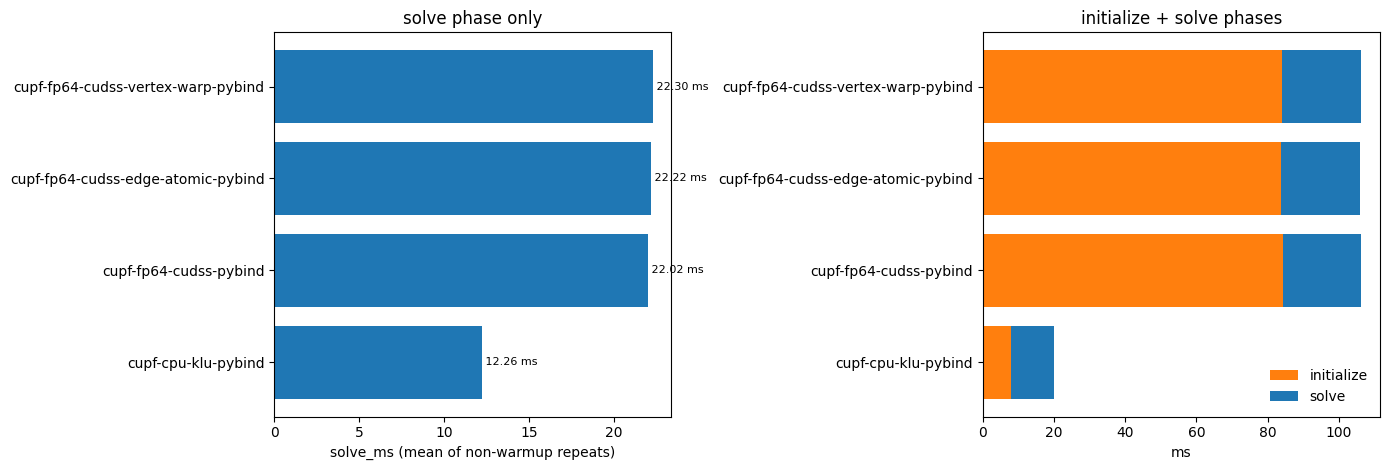

In [4]:
variants = [
    'cupf-cpu-klu-pybind',
    'cupf-fp64-cudss-pybind',
    'cupf-fp64-cudss-edge-atomic-pybind',
    'cupf-fp64-cudss-vertex-warp-pybind',
]
if RUN_BENCHMARKS:
    run_dir, command = tu.run_tutorial_benchmark(
        variants=variants,
        run_name=tu.timestamp_run_name('tutorial-gpu'),
        cases=[TUTORIAL_CASE],
        repeats=REPEATS,
        warmup=WARMUP,
        timeout=3600,
    )
    print(tu.command_summary(command, tail_lines=18))
else:
    run_dir = tu.tutorial_output_root()

summary = tu.benchmark_result_table(run_dir)
display(summary[['variant', 'status', 'linear_solver', 'jacobian', 'initialize_ms', 'solve_ms', 'worst_residual', 'note']])
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
tu.plot_variant_timing(summary, axes[0], 'solve phase only')
tu.plot_init_solve_stack(summary, axes[1], 'initialize + solve phases')
plt.tight_layout()


In [5]:
comparison = tu.solve_comparison_table(summary, baseline_variant='cupf-cpu-klu-pybind')
if not comparison.empty:
    comparison['variant_key'] = comparison['variant'].str.replace('-pybind', '', regex=False)
    cpu_row = comparison[comparison['variant_key'] == 'cupf-cpu-klu']
    if not cpu_row.empty:
        cpu_init = float(cpu_row['initialize_ms'].iloc[0])
        cpu_solve = float(cpu_row['solve_ms'].iloc[0])
        comparison['initialize_ratio_to_cpu'] = comparison['initialize_ms'] / cpu_init if cpu_init > 0 else np.nan
        comparison['solve_ratio_to_cpu'] = comparison['solve_ms'] / cpu_solve if cpu_solve > 0 else np.nan

display(comparison.round({
    'initialize_ms': 3,
    'solve_ms': 3,
    'initialize_ratio_to_cpu': 2,
    'solve_ratio_to_cpu': 2,
}))


,variant,initialize_ms,solve_ms,linear_solver,jacobian,solve_ratio_to_baseline,variant_key,initialize_ratio_to_cpu,solve_ratio_to_cpu
0,cupf-cpu-klu-pybind,7.788,12.257,klu,native,1.000000,cupf-cpu-klu,1.00,1.00
1,cupf-fp64-cudss-pybind,84.176,22.025,cudss,edge,1.796971,cupf-fp64-cudss,10.81,1.80
2,cupf-fp64-cudss-edge-atomic-pybind,83.745,22.216,cudss,edge_atomic,1.812570,cupf-fp64-cudss-edge-atomic,10.75,1.81
3,cupf-fp64-cudss-vertex-warp-pybind,83.960,22.299,cudss,vertex_warp,1.819319,cupf-fp64-cudss-vertex-warp,10.78,1.82


**cuDSS / Edge / Vertex 결과 해석**
- 위 ratio table은 CPU KLU를 기준으로 `initialize_ms`와 `solve_ms`를 따로 비교한다.
- 현재 저장된 출력에서는 FP64 cuDSS 계열이 CPU KLU보다 initialize phase와 solve phase 모두 길다.
- 따라서 이 결과는 `초기화만 비싸고 solve는 빠르다`가 아니다.
- 이 케이스와 이 runner에서는 반복 solve 구간까지 CPU KLU가 더 짧다.
- Edge, EdgeAtomic, VertexWarp 사이의 solve time 차이는 작다.
- 이는 stage timer 없이 aggregate `solve_ms`만 보고 내리는 추론이지만, 현재 결과에서는 Jacobian fill 방식보다 cuDSS numeric factorization/solve 쪽이 더 크게 보인다는 해석이 자연스럽다.


**Custom solver 비교의 위치**
- 본문 결론의 필수 조건은 아니다.
- 성공하면 cuDSS 대비 initialize/solve phase를 따로 비교한다.
- 실패하면 custom path가 추가 build/runtime dependency를 요구한다는 정보로 남긴다.


In [6]:
custom_build = tu.build_eval('gpu-custom', jobs=2, timeout=3600)
print(tu.command_summary(custom_build, tail_lines=12))
custom_summary = pd.DataFrame()
if custom_build.ok and RUN_BENCHMARKS:
    custom_dir, custom_command = tu.run_tutorial_benchmark(
        variants=['cupf-fp64-custom-pybind'],
        run_name=tu.timestamp_run_name('tutorial-gpu-custom'),
        cases=[TUTORIAL_CASE],
        repeats=REPEATS,
        warmup=WARMUP,
        timeout=3600,
    )
    print(tu.command_summary(custom_command, tail_lines=18))
    custom_summary = tu.benchmark_result_table(custom_dir)
    display(custom_summary)
else:
    print('custom solver comparison is unavailable in this environment/build.')


$ bash benchmark/scripts/build_eval.bash gpu-custom --jobs 2
[OK] elapsed=0.4s
[ 25%] Built target custom_linear_solver_ops
Consolidate compiler generated dependencies of target cupf
[ 92%] Built target cupf
Consolidate compiler generated dependencies of target _cupf
[100%] Built target _cupf
[ 25%] Built target custom_linear_solver_ops
[ 90%] Built target cupf
Consolidate compiler generated dependencies of target cupf_cpp_evaluate
[100%] Built target cupf_cpp_evaluate
[build_eval] done. artifacts under /workspace/gpu-powerflow-master/cuPF/build/eval-gpu-custom
[build_eval]   /workspace/gpu-powerflow-master/cuPF/build/eval-gpu-custom/tests/cupf_cpp_evaluate
[build_eval]   /workspace/gpu-powerflow-master/cuPF/build/eval-gpu-custom/_cupf.cpython-310-x86_64-linux-gnu.so


$ /usr/bin/python3 -m python.tests.run_benchmark --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --run-name tutorial-gpu-custom-20260601-140533 --cases case6468rte --repeats 1 --warmup 0 --variants cupf-fp64-custom-pybind
[OK] elapsed=4.1s
[benchmark][RUN] /usr/bin/python3 -m python.tests.run_cupf_pybind --dataset-root /datasets/matpower --run-name tutorial-gpu-custom-20260601-140533 --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --warmup 0 --repeats 1 --tolerance 1e-08 --max-iter 50 --reference-tolerance 1e-10 --reference-max-iter 80 --no-aggregate --cases case6468rte --variants cupf-fp64-custom-pybind
[cupf-fp64-custom-pybind][OK] case6468rte repeat=0 init_ms=21.870 solve_ms=7.984 iters=4 resid=7.127e-12
[cupf-fp64-custom-pybind] wrote /workspace/gpu-powerflow-master/python/tutorial/_runs/tutorial-gpu-custom-20260601-140533/cupf-fp64-custom-pybind/runs.csv
[aggregate] 1 rows -> /workspace/gpu-powerflow-master/python/tutorial/_runs/tutorial-gpu

,variant,cases,successful_rows,converged_rows,initialize_ms,solve_ms,worst_residual,linear_solver,jacobian,entrypoint,status,note
0,cupf-fp64-custom-pybind,1,1,1,21.870409,7.984175,7.126537e-12,custom,edge,pybind,ok,


In [7]:
custom_ok = tu.successful_variants(custom_summary) if 'custom_summary' in globals() else pd.DataFrame()
base_ok = tu.successful_variants(summary)
if not custom_ok.empty:
    custom_ok = custom_ok.copy()
    custom_ok['variant_key'] = custom_ok['variant'].str.replace('-pybind', '', regex=False)
if not base_ok.empty:
    base_ok = base_ok.copy()
    base_ok['variant_key'] = base_ok['variant'].str.replace('-pybind', '', regex=False)

custom_compare = pd.DataFrame()
if not custom_ok.empty and not base_ok.empty and 'cupf-fp64-cudss' in set(base_ok['variant_key']):
    custom_row = custom_ok.iloc[0]
    cudss_row = base_ok.loc[base_ok['variant_key'] == 'cupf-fp64-cudss'].iloc[0]
    custom_compare = pd.DataFrame([
        {
            'phase': 'initialize',
            'cudss_ms': float(cudss_row['initialize_ms']),
            'custom_ms': float(custom_row['initialize_ms']),
            'cudss_to_custom_ratio': float(cudss_row['initialize_ms']) / float(custom_row['initialize_ms']),
        },
        {
            'phase': 'solve',
            'cudss_ms': float(cudss_row['solve_ms']),
            'custom_ms': float(custom_row['solve_ms']),
            'cudss_to_custom_ratio': float(cudss_row['solve_ms']) / float(custom_row['solve_ms']),
        },
    ])

display(custom_compare.round({'cudss_ms': 3, 'custom_ms': 3, 'cudss_to_custom_ratio': 2}))


,phase,cudss_ms,custom_ms,cudss_to_custom_ratio
0,initialize,84.176,21.870,3.85
1,solve,22.025,7.984,2.76


**Custom solver 결과 해석**
- custom solver는 연구용 비교점이다.
- 현재 저장된 출력에서는 custom path가 cuDSS보다 initialize phase와 solve phase 모두 짧다.
- 이 숫자는 가능성의 신호이지 최종 성능 결론은 아니다.
- `repeats=1`이고, custom solver path는 build/runtime 조건의 영향을 더 받을 수 있다.
- 그래도 방향성은 분명하다: cuDSS가 큰 비중을 차지하면, 전력계통 Jacobian 구조를 더 강하게 이용하는 linear solver 연구가 중요해진다.


**GPU 결과 해석**
- 결론은 자동 가속이 아니다.
- `initialize_ms`가 크면 같은 topology를 여러 scenario에 재사용하는 구조가 중요하다.
- `solve_ms`가 크면 Newton 반복 안의 numeric factorization/linear solve가 다음 병목이다.
- Edge/Vertex Jacobian 차이가 작고 custom solver가 solve phase에서 짧게 나오면, 연구 방향은 Jacobian fill kernel보다 전력계통 구조를 이용한 linear solver 쪽으로 더 강하게 이동한다.
